In [64]:
#import keras
import tensorflow as tf
from tensorflow import keras
from IPython.display import Image
import matplotlib.pyplot as plt
#from keras import layers
#from keras import ops
from tensorflow.keras import layers
import os
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from keras.callbacks import CSVLogger
from PIL import Image
import seaborn as sns
import json

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
#todo - add a function that unzips the testing data for loading the test results

In [ ]:
load_test=False # !!IMPORTANT!! Set to True to load the models, False to test new ones 
# setting to False will delete existing files and force testing of the models 
load_train=False # !!IMPORTANT!! Set to True to load the training history, False to train new models

#To be able to load the data from the previous training, the file with the testing data needs to be unzipped

In [67]:
if not load_train: #clean up old files if we are not loading
    os.remove("model_1.keras") if os.path.exists("model_1.keras") else None
    os.remove("model_2.keras") if os.path.exists("model_2.keras") else None
    os.remove("model_3.keras") if os.path.exists("model_3.keras") else None
    os.remove("training_1.log") if os.path.exists("training_1.log") else None
    os.remove("training_2.log") if os.path.exists("training_2.log") else None
    os.remove("training_3.log") if os.path.exists("training_3.log") else None
    os.remove("best_lr.json") if os.path.exists("best_lr.json") else None
    os.remove("best_model.keras") if os.path.exists("best_model.keras") else None
if not load_test: #clean up old files if we are not loading
    if not os.path.exists("./performance"):
        os.makedirs("./performance")
    os.remove("./performance/y_pred_1.json") if os.path.exists("./performance/y_pred_1.json") else None
    os.remove("./performance/y_pred_2.json") if os.path.exists("./performance/y_pred_2.json") else None
    os.remove("./performance/y_pred_3.json") if os.path.exists("./performance/y_pred_3.json") else None
    os.remove("./performance/y_pred_personalized_1.json") if os.path.exists("./performance/y_pred_personalized_1.json") else None
    os.remove("./performance/y_pred_personalized_2.json") if os.path.exists("./performance/y_pred_personalized_2.json") else None
    os.remove("./performance/y_pred_personalized.json") if os.path.exists("./performance/y_pred_personalized.json") else None
    os.remove("./performance/y_pred_personalized_b_1.json") if os.path.exists("./performance/y_pred_personalized_b_1.json") else None
    os.remove("./performance/y_pred_personalized_b_2.json") if os.path.exists("./performance/y_pred_personalized_b_2.json") else None
    os.remove("./performance/y_pred_personalized_b.json") if os.path.exists("./performance/y_pred_personalized_b.json") else None

<h1>Analyzing the dataset</h1>

In [68]:
paper= Image.open('./train/paper/2IOsxsG8AaxntdJM.png')
paper.show()
rock= Image.open('./train/rock/2DdERUV7Te8ivywq.png')
rock.show()
scissors= Image.open('./train/scissors/2DEYFsJ27UgVqv3W.png')
scissors.show()



In [69]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="training",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="validation",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_size = len(temp_ds)

val_size = temp_size // 2

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Found 2188 files belonging to 3 classes.
Using 1532 files for training.
Found 2188 files belonging to 3 classes.
Using 656 files for validation.


Try running the update-desktop-database command. If you
don't have this command you should install the
desktop-file-utils package. This package is available from
http://freedesktop.org/wiki/Software/desktop-file-utils/
Try running the update-desktop-database command. If you
don't have this command you should install the
desktop-file-utils package. This package is available from
http://freedesktop.org/wiki/Software/desktop-file-utils/
Try running the update-desktop-database command. If you
don't have this command you should install the
desktop-file-utils package. This package is available from
http://freedesktop.org/wiki/Software/desktop-file-utils/
No applications found for mimetype: image/png
.No applications found for mimetype: image/png
.No applications found for mimetype: image/png
.

/usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: iceweasel: not found


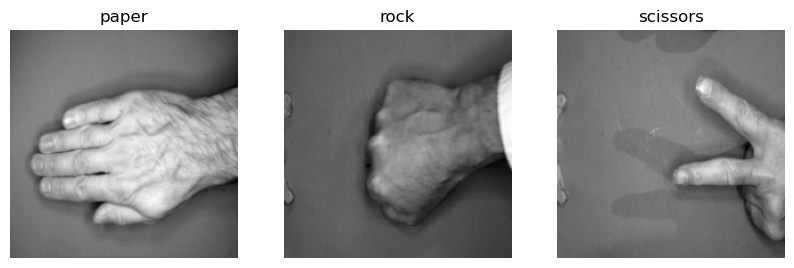

/usr/bin/xdg-open: 882: iceweasel: not found


In [70]:
class_names = train_ds.class_names
# Display one image per class
shown_classes = set()
plt.figure(figsize=(10, 4))
for images, labels in train_ds.unbatch():
    label = labels.numpy()
    if label not in shown_classes:
        plt.subplot(1, len(class_names), len(shown_classes) + 1)
        plt.imshow(images.numpy().squeeze(), cmap="gray")  
        plt.title(class_names[label])
        plt.axis("off")
        shown_classes.add(label)
    if len(shown_classes) == len(class_names):
        break
plt.show()

<h2>Model 1 architecture and training</h2>

In [71]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.4),
    layers.RandomContrast(0.4)
])

/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: seamonkey: not found


In [72]:

if os.path.exists("model_1.keras"):
    model_1 = keras.models.load_model("model_1.keras")
    history_1 = pd.read_csv('./training_1.log',sep=',',engine='python')
else:
    model_1 = keras.Sequential(
        [
        
        layers.Rescaling(1./255),
        layers.Resizing(96, 96),        
       layers.Conv2D(16, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(96, 96, 1)),
       layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu",kernel_initializer='he_normal'),
        layers.Dense(3,activation='softmax')
    
        ]
    )
    csv_logger_1 = CSVLogger('training_1.log', separator=',', append=False)
    model_1.summary()
    model_1.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    history_1=model_1.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[csv_logger_1])
    history_1=history_1.history

/home/loren/miniconda3/envs/StatML/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: seamonkey: not found


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_7 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15


/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: /usr/bin/xdg-open: 882: konqueror: not found
epiphany: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found
/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: chromium-browser: not found
/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: elink

48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.3642 - loss: 2.0873 - val_accuracy: 0.6625 - val_loss: 0.9247
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6084 - loss: 0.8904 - val_accuracy: 0.6125 - val_loss: 0.8607
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7376 - loss: 0.7222 - val_accuracy: 0.7625 - val_loss: 0.6596
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7911 - loss: 0.5872 - val_accuracy: 0.7250 - val_loss: 0.6951
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8290 - loss: 0.5032 - val_accuracy: 0.8281 - val_loss: 0.5495
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8544 - loss: 0.4562 - val_accuracy: 0.8250 - val_loss: 0.4856
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8414 - loss: 0.4498 - val_accuracy: 0.7969 - val_loss: 0.5577
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8799 - loss: 0.3722 - val_accuracy: 0.8562 - val_loss: 0.

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


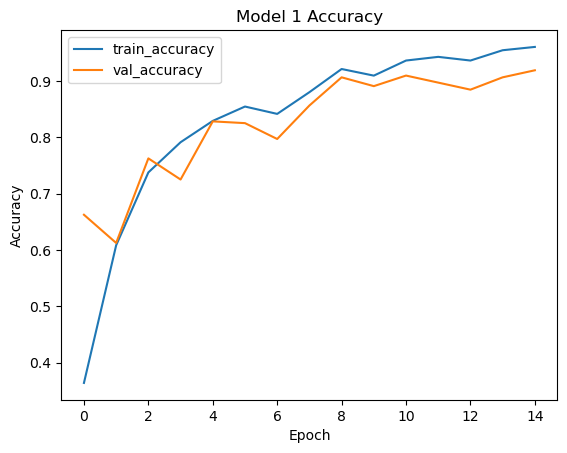

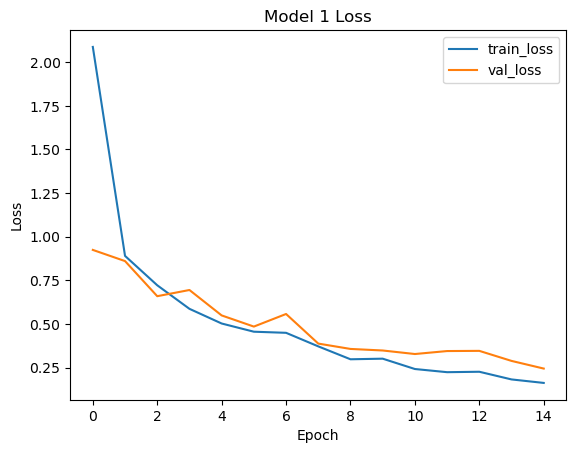

In [73]:
print(history_1.keys())
plt.title("Model 1 Accuracy")
plt.plot(history_1["accuracy"], label="train_accuracy")
plt.plot(history_1["val_accuracy"], label="val_accuracy")
#plt.ylim(0.8, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.title("Model 1 Loss")
plt.plot(history_1["loss"], label="train_loss")
plt.plot(history_1["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h3>Model 1 prediction</h3> 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
Predicted label: paper
Actual label: paper


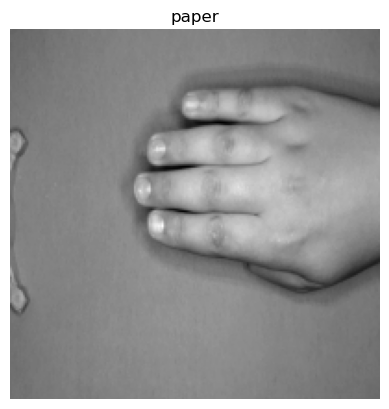

In [74]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_1.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

<h2>Model 2 architecture and training</h2>

In [75]:

if os.path.exists("model_2.keras"):
    model_2 = keras.models.load_model("model_2.keras")
    history_2 = pd.read_csv('./training_2.log',sep=',',engine='python')
else:
    model_2 = keras.Sequential(
        [
            data_augmentation,
        layers.Rescaling(1./255),
       layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(128, 128, 1)),
       layers.MaxPooling2D((2, 2)),
       layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
       layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu",kernel_initializer='he_normal'),

        layers.Dense(3,activation='softmax')

        ]
    )
    csv_logger_2 = CSVLogger('training_2.log', separator=',', append=False)
    model_2.summary()

    model_2.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_2=model_2.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[csv_logger_2])
    history_2=history_2.history

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.3916 - loss: 7.3750 - val_accuracy: 0.5562 - val_loss: 1.0803
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5509 - loss: 0.9492 - val_accuracy: 0.8438 - val_loss: 0.7276
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6893 - loss: 0.7566 - val_accuracy: 0.7812 - val_loss: 0.6654
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ -1s -28648us/step - accuracy: 0.7239 - loss: 0.6790 - val_accuracy: 0.8344 - val_loss: 0.5838
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7435 - loss: 0.6554 - val_accuracy: 0.7969 - val_loss: 0.5462
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8153 - loss: 0.5330 - val_accuracy: 0.9281 - val_loss: 0.3325
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8518 - loss: 0.4642 - val_accuracy: 0.9250 - val_loss: 0.3022
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8747 - loss: 0.3583 - val_accuracy: 0.953

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


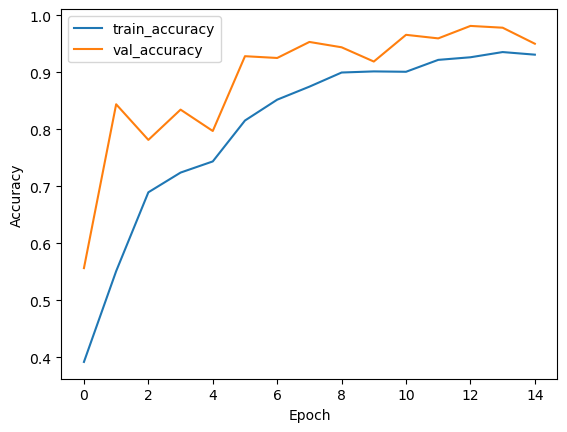

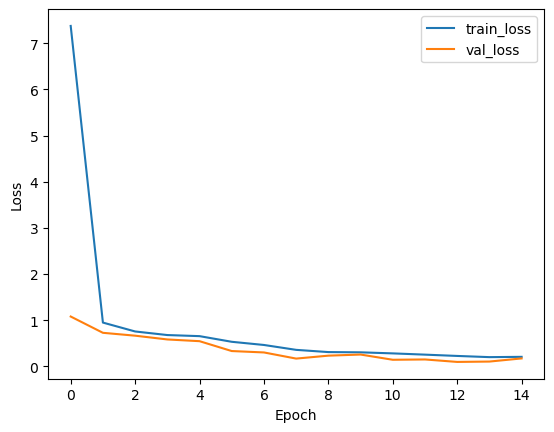

In [76]:
print(history_2.keys())
plt.plot(history_2["accuracy"], label="train_accuracy")
plt.plot(history_2["val_accuracy"], label="val_accuracy")
#plt.ylim(0.9, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.plot(history_2["loss"], label="train_loss")
plt.plot(history_2["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h3>Model 2 prediction </h3>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predicted label: rock
Actual label: rock


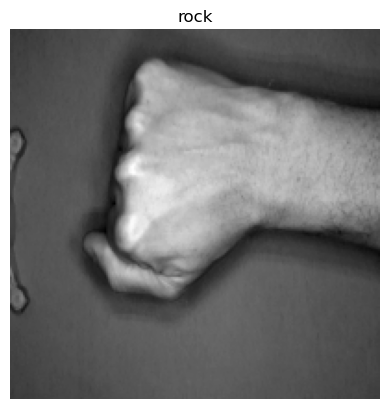

In [77]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_2.predict(image[None, ...])
    

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

<h2>Model 3 architecture and training</h2>

<h3>Finding The best learning rate using grid-search</h3>

In [78]:

if os.path.exists("best_lr.json"):
    best_params = json.load(open('best_lr.json', 'r'))
    best_lr = best_params['best_lr']
    best_val_acc = best_params['best_val_acc']
else:
    lr_arr=[1e-5, 1e-4, 1e-3, 3e-3]
    best_val_acc = 0
    best_lr = None
    for lr in lr_arr:
        model_4 =keras.Sequential([

        data_augmentation,
        layers.Rescaling(1./255),
        layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(200, 200, 1)),
        layers.MaxPooling2D((2, 2)), 
       
        layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu',kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu',kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
       
        layers.Dense(512, activation="relu",name='dense_2',kernel_initializer='he_normal'),
        layers.Dropout(0.4),
        layers.Dense(256, activation="relu",name='dense_3',kernel_initializer='he_normal'),
        layers.Dropout(0.4),
      
        layers.Dense(3, activation='softmax')
    ])

        model_4.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]

        )
        
        history_4=model_4.fit(train_ds, validation_data=val_ds, epochs=15)
        history_4=history_4.history

        # Update best learning rate if current model performs better
        if max(history_4['val_accuracy'])  > best_val_acc:
            best_val_acc = max(history_4['val_accuracy'])
            best_lr = lr
    json.dump({'best_lr': best_lr, 'best_val_acc': best_val_acc}, open('best_lr.json', 'w'))


Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.3518 - loss: 1.4570 - val_accuracy: 0.4094 - val_loss: 1.0836
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.3721 - loss: 1.1646 - val_accuracy: 0.6469 - val_loss: 1.0267
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.4073 - loss: 1.1123 - val_accuracy: 0.5250 - val_loss: 1.0134
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4491 - loss: 1.0612 - val_accuracy: 0.7750 - val_loss: 0.9827
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4628 - loss: 1.0399 - val_accuracy: 0.6406 - val_loss: 0.9508
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5131 - loss: 0.9884 - val_accuracy: 0.7469 - val_loss: 0.9042
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ -1s -23626us/step - accuracy: 0.5725 - loss: 0.9478 - val_accuracy: 0.7281 - val_loss: 0.8527
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6090 - loss: 0.8849 - val_accuracy: 0.815

In [79]:
early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    mode='max',
    patience=4,
    restore_best_weights=True
)

lr_sched = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

ckpt = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

In [80]:
if os.path.exists("model_3.keras"):
    model_3 = keras.models.load_model("model_3.keras")
    history_3 = pd.read_csv('./training_3.log',sep=',',engine='python')
else:
    model_3 = keras.Sequential([

        data_augmentation,
        layers.Rescaling(1./255),
        layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(200, 200, 1)),
        layers.MaxPooling2D((2, 2)), 
        
        layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu',kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu',kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        
        layers.Dense(512, activation="relu",name='dense_2',kernel_initializer='he_normal'),
        layers.Dropout(0.4),
        layers.Dense(256, activation="relu",name='dense_3',kernel_initializer='he_normal'),
        layers.Dropout(0.4),
      
        layers.Dense(3, activation='softmax')
    ])
    csv_logger_3 = CSVLogger('training_3.log', separator=',', append=False)

    model_3.summary()
    model_3.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
        
    )
    history_3=model_3.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[csv_logger_3 , early_stop, lr_sched, ckpt])
    history_3=history_3.history

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_13 (Rescaling)        │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 198, 198, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    13,107,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,627,651 (51.99 MB)

 Trainable params: 13,627,651 (51.99 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.3590 - loss: 1.2494 - val_accuracy: 0.6750 - val_loss: 1.0708 - learning_rate: 1.0000e-04
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.4530 - loss: 1.0558 - val_accuracy: 0.6344 - val_loss: 0.9657 - learning_rate: 1.0000e-04
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.5601 - loss: 0.9316 - val_accuracy: 0.8906 - val_loss: 0.7128 - learning_rate: 1.0000e-04
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7193 - loss: 0.6994 - val_accuracy: 0.9125 - val_loss: 0.4660 - learning_rate: 1.0000e-04
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.7957 - loss: 0.5560 - val_accuracy: 0.9500 - val_loss: 0.3189 - learning_rate: 1.0000e-04
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8277 - loss: 0.4770 - val_accuracy: 0.9625 - val_loss: 0.3181 - learning_rate: 1.0000e-04
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.8675 -

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


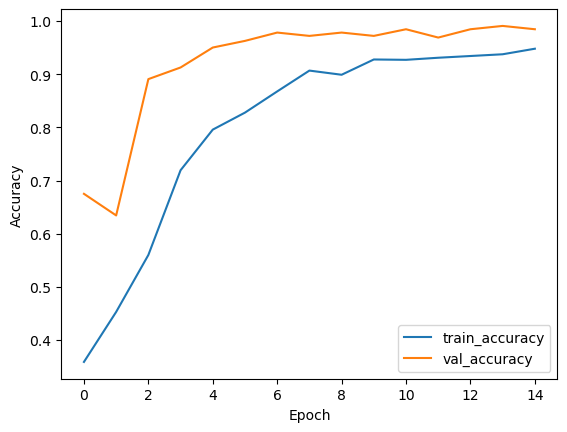

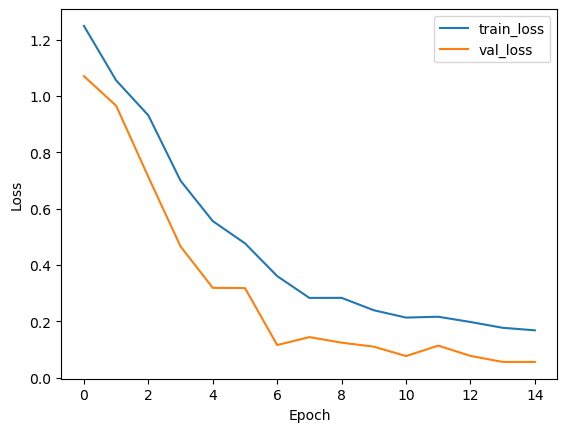

In [81]:
print(history_3.keys())
plt.plot(history_3["accuracy"], label="train_accuracy")
plt.plot(history_3["val_accuracy"], label="val_accuracy")
#plt.ylim(0.9, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.plot(history_3["loss"], label="train_loss")
plt.plot(history_3["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h3>Model 3 prediction</h3>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Predicted label: paper
Actual label: paper


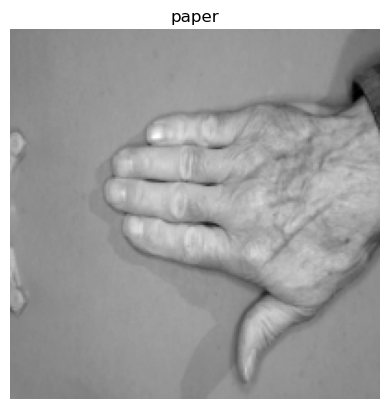

In [82]:

for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_3.predict(image[None, ...])
    

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()
    

<h2>Models testing</h2>

In [83]:



if load_test:
   y_pred_1 = np.array(json.load(open('./performance/y_pred_1.json', 'r')))
   y_pred_2 = np.array(json.load(open('./performance/y_pred_2.json', 'r')))
   y_pred_3 = np.array(json.load(open('./performance/y_pred_3.json', 'r')))
else: 
    y_test=[]
    img_test=[]
    y_pred_1=[]
    y_pred_2=[]
    y_pred_3=[]
    for images, labels in test_ds.unbatch():
        y_test.append(labels.numpy())
        img_test.append(images.numpy())
        y_pred_1.append(np.argmax(model_1.predict(images[None, ...])[0]))
        y_pred_2.append(np.argmax(model_2.predict(images[None, ...])[0]))
        y_pred_3.append(np.argmax(model_3.predict(images[None, ...])[0]))

    y_pred_1 = np.array(y_pred_1)
    y_pred_2 = np.array(y_pred_2)
    y_pred_3 = np.array(y_pred_3)
    y_test = np.array(y_test)
    img_test=np.array(img_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━

<h3>Testing on a custom dataset with different backgrounds</h3>

In [84]:

personalized_data = tf.keras.utils.image_dataset_from_directory(
    "test-personal",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

Found 47 files belonging to 3 classes.


Actual label: paper


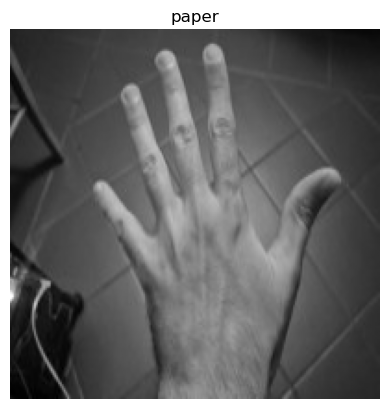

In [85]:
for images, labels in personalized_data.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    print(f"Actual label: {class_names[label]}")
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()
    

In [86]:
y_personalized=[]
img_personalized=[]

for images, labels in personalized_data.unbatch():
    y_personalized.append(labels.numpy())
    img_personalized.append(images.numpy())
y_personalized = np.array(y_personalized)
img_personalized=np.array(img_personalized)

if load_test:
    y_pred_personalized_1 = np.array(json.load(open('./performance/y_pred_personalized_1.json', 'r')))
    y_pred_personalized_2 = np.array(json.load(open('./performance/y_pred_personalized_2.json', 'r')))
    y_pred_personalized = np.array(json.load(open('./performance/y_pred_personalized.json', 'r')))
else:
    y_pred_personalized_1=[]
    y_pred_personalized_2=[]
    y_pred_personalized=[]

    for images, labels in zip(img_personalized, y_personalized):
        y_pred_personalized.append(np.argmax(model_3.predict(images[None, ...])[0]))
        y_pred_personalized_1.append(np.argmax(model_1.predict(images[None, ...])[0]))
        y_pred_personalized_2.append(np.argmax(model_2.predict(images[None, ...])[0]))

    y_pred_personalized = np.array(y_pred_personalized)
    y_pred_personalized_1 = np.array(y_pred_personalized_1)
    y_pred_personalized_2 = np.array(y_pred_personalized_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━

<h3>Testing on a dataset with images with homogeneous beckgrounds and drastic orientation changes</h3>

In [87]:

personalized_data_b = tf.keras.utils.image_dataset_from_directory(
    "test-black-bg",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

Found 70 files belonging to 3 classes.


Actual label: paper


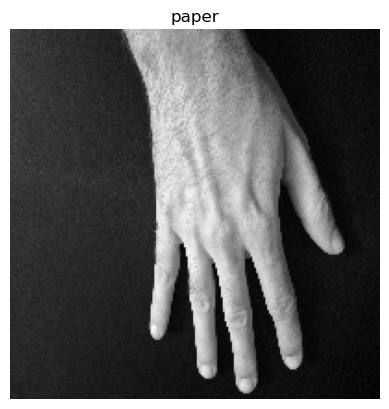

In [88]:
for images, labels in personalized_data_b.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    print(f"Actual label: {class_names[label]}")
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

In [89]:
img_personalized_b=[]
y_personalized_b=[]

for images, labels in personalized_data_b.unbatch():
    y_personalized_b.append(labels.numpy())
    img_personalized_b.append(images.numpy())
y_personalized_b = np.array(y_personalized_b)
img_personalized_b=np.array(img_personalized_b)

if load_test:
    y_pred_personalized_b_1 = np.array(json.load(open('./performance/y_pred_personalized_b_1.json', 'r')))
    y_pred_personalized_b_2 = np.array(json.load(open('./performance/y_pred_personalized_b_2.json', 'r')))
    y_pred_personalized_b = np.array(json.load(open('./performance/y_pred_personalized_b.json', 'r')))

else:
    y_pred_personalized_b_2=[]
    y_pred_personalized_b_1=[]
    y_pred_personalized_b=[]

    for images, labels in zip(img_personalized_b, y_personalized_b):
        y_pred_personalized_b.append(np.argmax(model_3.predict(images[None, ...])[0]))
        y_pred_personalized_b_1.append(np.argmax(model_1.predict(images[None, ...])[0]))
        y_pred_personalized_b_2.append(np.argmax(model_2.predict(images[None, ...])[0]))

    y_pred_personalized_b = np.array(y_pred_personalized_b)
    y_pred_personalized_b_1 = np.array(y_pred_personalized_b_1)
    y_pred_personalized_b_2 = np.array(y_pred_personalized_b_2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


2026-05-25 22:51:34.888630: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━

<h2>Performance evaluation</h2>

<h3>Model 1 performance</h3>

In [90]:
def metrics_from_confusion(cm):
    tp = np.diag(cm)
    fp = np.sum(cm, axis=0) - tp
    fn = np.sum(cm, axis=1) - tp

    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) != 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp + fn) != 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp, dtype=float), where=(precision + recall) != 0)

    accuracy = np.sum(tp) / np.sum(cm)

    return precision, recall, f1, accuracy

In [91]:
result_1=confusion_matrix(y_test, y_pred_1,labels=[0,1,2])

In [92]:
incorrect_indices_1 = np.where(y_pred_1 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_1)} out of {len(y_test)}")

Incorrectly classified samples: 32 out of 336


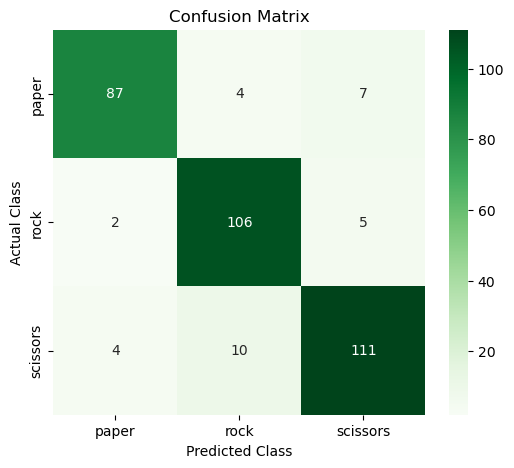

In [93]:

p=[('Predicted', x)  for x in class_names]
b=[('Actual', x)  for x in class_names]
df = pd.DataFrame(result_1, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model1_cf=np.array(pd.DataFrame(result_1,columns=class_names,index=class_names))
plt.figure(figsize=(6,5))
sns.heatmap(result_1, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


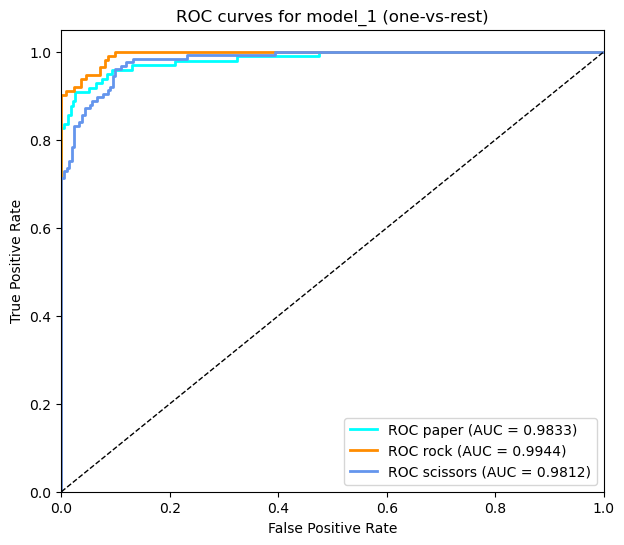

AUC per class:
  paper: 0.9833
  rock: 0.9944
  scissors: 0.9812
Micro AUC: 0.9870
Macro AUC: 0.9863


In [94]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# If model_1 needs 96x96 and you want to resize explicitly, uncomment:
# img_test_resized = tf.image.resize(img_test, (96, 96)).numpy()
# y_score = model_1.predict(img_test_resized)

y_score = model_1.predict(img_test)  # predicted probabilities

fpr = dict(); tpr = dict(); roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

roc_auc["micro"] = roc_auc_score(y_test_bin, y_score, average="micro", multi_class="ovr")
roc_auc["macro"] = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")

colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
plt.figure(figsize=(7,6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlim([0.0,1.0]); plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves for model_1 (one-vs-rest)')
plt.legend(loc='lower right')
plt.show()

print('AUC per class:')
for i in range(n_classes):
    print(f'  {class_names[i]}: {roc_auc[i]:.4f}')
print(f"Micro AUC: {roc_auc['micro']:.4f}")
print(f"Macro AUC: {roc_auc['macro']:.4f}")


In [95]:
precision, recall, f1, accuracy = metrics_from_confusion(result_1)
print(f'------------------------model 1 performance metrics (from confusion matrix)------------------------')
print(f'precision = {np.mean(precision)}')
print(f'recall = {np.mean(recall)}')
print(f'accuracy = {accuracy}')
print(f'f1_score = {np.mean(f1)}')  


------------------------model 1 performance metrics (from confusion matrix)------------------------
precision = 0.907085409563773
recall = 0.9046027331286496
accuracy = 0.9047619047619048
f1_score = 0.9053424331185598


<h3>Model 2 performance</h3>

In [96]:
result_2=confusion_matrix(y_test, y_pred_2)

In [97]:
incorrect_indices_2 = np.where(y_pred_2 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_2)} out of {len(y_test)}")

Incorrectly classified samples: 15 out of 336


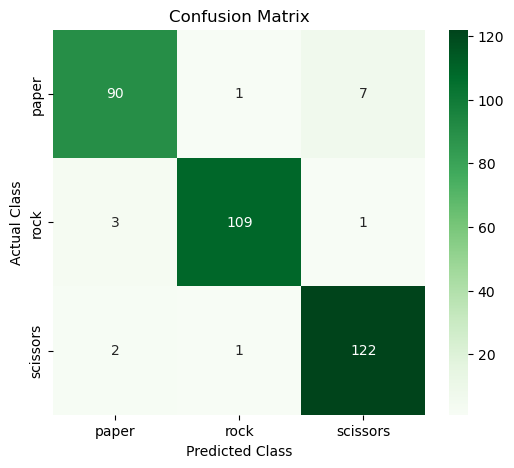

In [98]:
p=[('Predicted', x)  for x in class_names]
b=[('Real', x)  for x in class_names]
df = pd.DataFrame(result_2, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model2_cf=np.array(pd.DataFrame(result_2,columns=class_names,index=class_names))

plt.figure(figsize=(6,5))
sns.heatmap(result_2, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


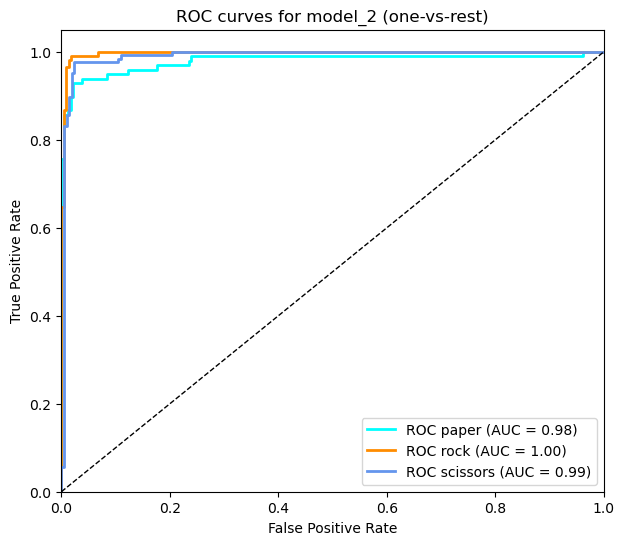

AUC per class:
  paper: 0.9793
  rock: 0.9971
  scissors: 0.9906
Micro AUC: 0.9895
Macro AUC: 0.9890


In [99]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))
y_score = model_2.predict(img_test)  # predicted probabilities

fpr = dict(); tpr = dict(); roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

roc_auc["micro"] = roc_auc_score(y_test_bin, y_score, average="micro", multi_class="ovr")
roc_auc["macro"] = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")

colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
plt.figure(figsize=(7,6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlim([0.0,1.0]); plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves for model_2 (one-vs-rest)')
plt.legend(loc='lower right')
plt.show()

print('AUC per class:')
for i in range(n_classes):
    print(f'  {class_names[i]}: {roc_auc[i]:.4f}')
print(f"Micro AUC: {roc_auc['micro']:.4f}")
print(f"Macro AUC: {roc_auc['macro']:.4f}")

In [100]:
precision, recall, f1, accuracy = metrics_from_confusion(result_2)
print(f'------------------------model 2 performance metrics (from confusion matrix)------------------------')
print(f'precision = {np.mean(precision)}')
print(f'recall = {np.mean(recall)}')
print(f'accuracy = {accuracy}')
print(f'f1_score = {np.mean(f1)}')

------------------------model 2 performance metrics (from confusion matrix)------------------------
precision = 0.9559373138320506
recall = 0.9529897056167599
accuracy = 0.9553571428571429
f1_score = 0.954239839286319


<h3>Model 3 performance </h3>

In [101]:

result_3=confusion_matrix(y_test, y_pred_3)

In [102]:
incorrect_indices_3 = np.where(y_pred_3 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_3)} out of {len(y_test)}")


Incorrectly classified samples: 8 out of 336


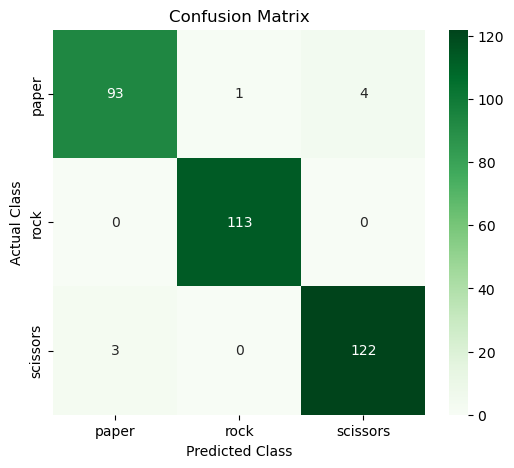

In [103]:
p=[('Predicted', x)  for x in class_names]
b=[('Real', x)  for x in class_names]
df = pd.DataFrame(result_3, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model3_cf=np.array(pd.DataFrame(result_3,columns=class_names,index=class_names))

plt.figure(figsize=(6,5))
sns.heatmap(result_3, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


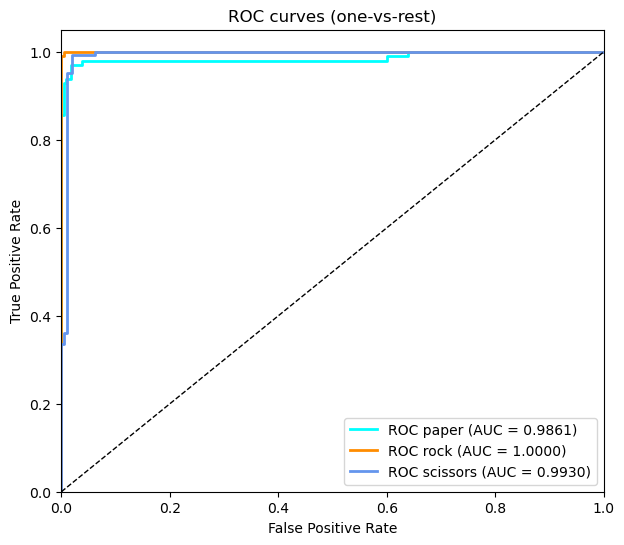

AUC per class:
  paper: 0.9861
  rock: 1.0000
  scissors: 0.9930
Micro AUC: 0.9947
Macro AUC: 0.9930


In [104]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# number of classes
n_classes = 3

# binarize true labels (shape: [n_samples, n_classes])
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# predicted probabilities from the model (model already includes Rescaling)
y_score = model_3.predict(img_test)  # shape: (n_samples, n_classes)

# compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes): #One vs rest approach, treat class i as positive and the rest as negative
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# micro- and macro-averaged AUC (multiclass)
#micro auc: aggregates contributions from all classes and computes a global average
# macro auc: computes AUC for each class and averages them, treating all classes equally regardless of their frequency  
roc_auc["micro"] = roc_auc_score(y_test_bin, y_score, average="micro", multi_class="ovr")
roc_auc["macro"] = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")

# Plot per-class ROC
colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
plt.figure(figsize=(7,6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves (one-vs-rest)')
plt.legend(loc='lower right')
plt.show()

# Print summary AUCs
print('AUC per class:')
for i in range(n_classes):
    print(f'  {class_names[i]}: {roc_auc[i]:.4f}')
print(f"Micro AUC: {roc_auc['micro']:.4f}")
print(f"Macro AUC: {roc_auc['macro']:.4f}")

In [105]:
precision, recall, f1, accuracy = metrics_from_confusion(result_3)
print(f'------------------------model 3 performance metrics (from confusion matrix)------------------------')
print(f'precision = {np.mean(precision)}')
print(f'recall = {np.mean(recall)}')
print(f'accuracy = {accuracy}')
print(f'f1_score = {np.mean(f1)}')

------------------------model 3 performance metrics (from confusion matrix)------------------------
precision = 0.9760773461431356
recall = 0.9749931972789115
accuracy = 0.9761904761904762
f1_score = 0.9754897180130621


<h3>Incorrect prediction analisys for model 3</h3>

<p>The error analisys is performed solely on model 3 for reading clrity reasons</p>

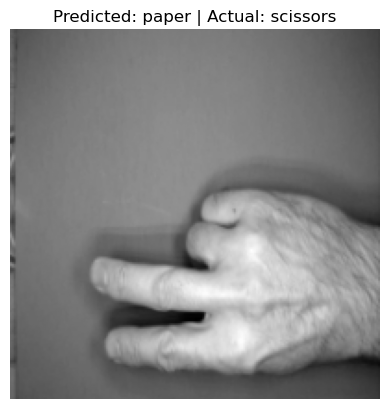

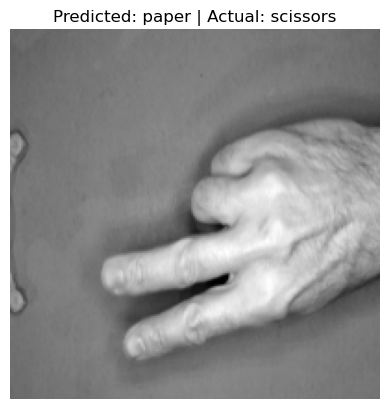

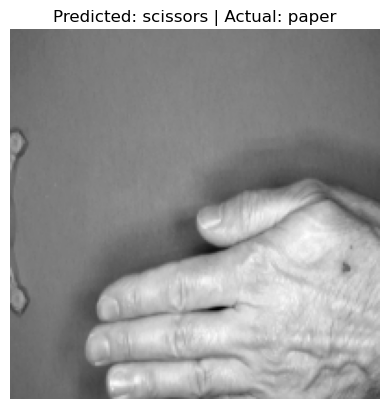

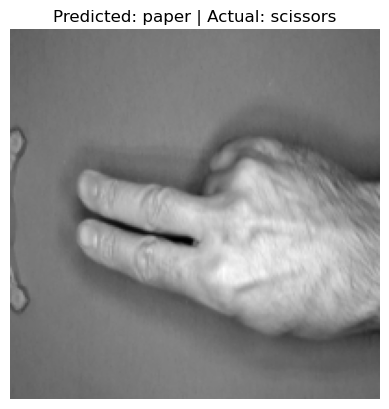

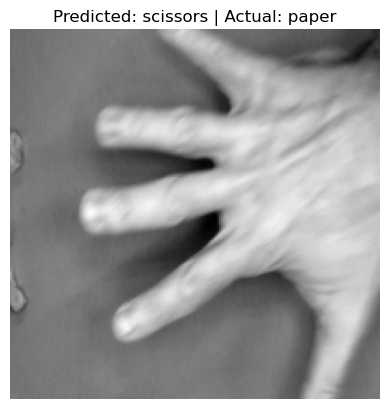

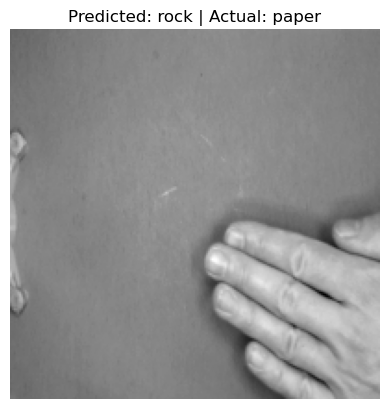

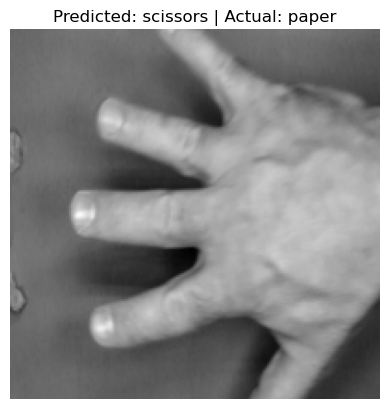

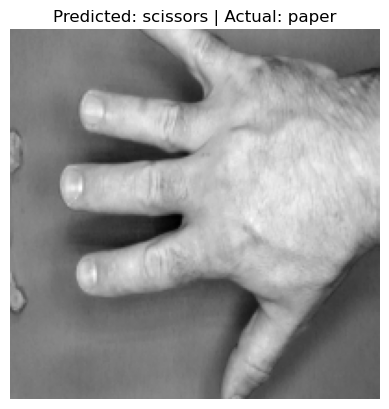

In [106]:
for idx in incorrect_indices_3:
    img=img_test[idx].squeeze()
    plt.imshow(img, cmap="gray")
    plt.title(f'Predicted: {class_names[y_pred_3[idx]]} | Actual: {class_names[y_test[idx]]}')
    plt.axis("off")
    plt.show()

<h2>Analisys on personalized datasets</h2>

<h3>Model 3 performance analisys on Noisy backgrounds and frequent rotations</h3>

In [107]:
result_personalized=confusion_matrix(y_personalized, y_pred_personalized,labels=[0,1,2])



Incorrectly classified samples: 28 out of 47


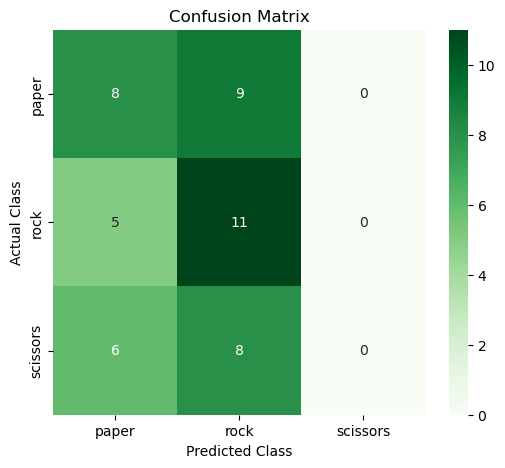

In [108]:
incorrect_indices_personalized = np.where(y_pred_personalized != y_personalized)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_personalized)} out of {len(y_personalized)}")
p=[('Predicted', x)  for x in class_names]
b=[('Actual', x)  for x in class_names]
df = pd.DataFrame(result_personalized, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model1_cf=np.array(pd.DataFrame(result_personalized,columns=class_names,index=class_names))
plt.figure(figsize=(6,5))
sns.heatmap(result_personalized, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()


In [109]:
precision, recall, f1, accuracy = metrics_from_confusion(result_personalized)
print(f'------------------------personalized dataset performance metrics (from confusion matrix)------------------------')
print(f'precision = {np.mean(precision)}')
print(f'recall = {np.mean(recall)}')
print(f'accuracy = {accuracy}')
print(f'f1_score = {np.mean(f1)}')

------------------------personalized dataset performance metrics (from confusion matrix)------------------------
precision = 0.2713032581453634
recall = 0.3860294117647059
accuracy = 0.40425531914893614
f1_score = 0.3148148148148148


<h3>Model 3 analisys on homogeneous backgrounds with frequent rotations</h3>

In [110]:
result_personalized_b=confusion_matrix(y_personalized_b, y_pred_personalized_b,labels=[0,1,2])



Incorrectly classified samples: 10 out of 70


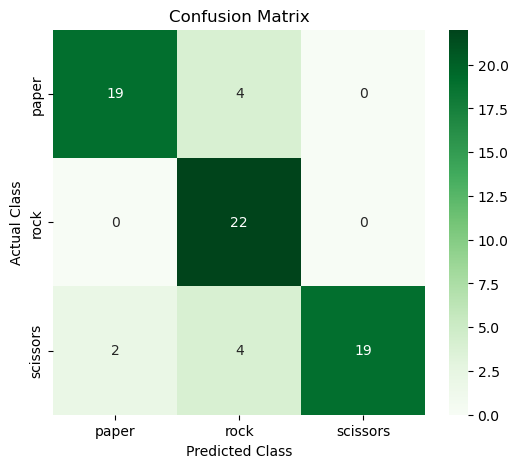

In [111]:
incorrect_indices_personalized_b = np.where(y_pred_personalized_b != y_personalized_b)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_personalized_b)} out of {len(y_personalized_b)}")
p=[('Predicted', x)  for x in class_names]
b=[('Actual', x)  for x in class_names]
df = pd.DataFrame(result_personalized_b, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model1_cf=np.array(pd.DataFrame(result_personalized_b,columns=class_names,index=class_names))
plt.figure(figsize=(6,5))
sns.heatmap(result_personalized_b, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()


In [112]:
precision, recall, f1, accuracy = metrics_from_confusion(result_personalized_b)
print(f'------------------------personalized dataset with black background performance metrics (from confusion matrix)----------------')

print(f'precision = {np.mean(precision)}')
print(f'recall = {np.mean(recall)}')
print(f'accuracy = {accuracy}')
print(f'f1_score = {np.mean(f1)}')

------------------------personalized dataset with black background performance metrics (from confusion matrix)----------------
precision = 0.8793650793650793
recall = 0.8620289855072464
accuracy = 0.8571428571428571
f1_score = 0.8578088578088577


<h4>Model 1 performance analisys on Noisy backgrounds and frequent rotations</h4>

In [113]:
result_personalized_1=confusion_matrix(y_personalized, y_pred_personalized_1,labels=[0,1,2])

Incorrectly classified samples: 29 out of 47


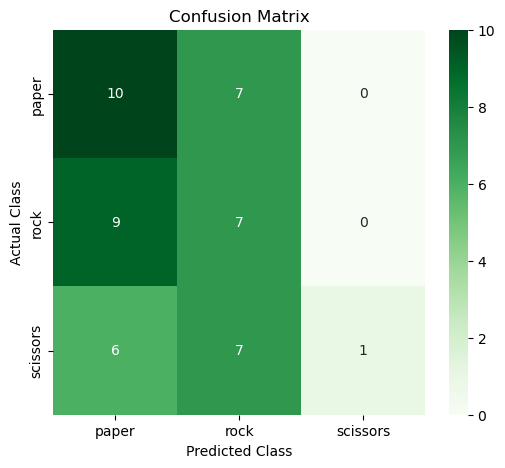

In [114]:
incorrect_indices_personalized_1 = np.where(y_pred_personalized_1 != y_personalized)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_personalized_1)} out of {len(y_personalized)}")
p=[('Predicted', x)  for x in class_names]
b=[('Actual', x)  for x in class_names]
df = pd.DataFrame(result_personalized_1, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model1_cf=np.array(pd.DataFrame(result_personalized_1,columns=class_names,index=class_names))
plt.figure(figsize=(6,5))
sns.heatmap(result_personalized_1, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()


In [115]:
precision, recall, f1, accuracy = metrics_from_confusion(result_personalized_1)
print(f'------------------------personalized dataset performance metrics for model 1 (from confusion matrix)------------------------')
print(f'precision = {np.mean(precision)}')
print(f'recall = {np.mean(recall)}')
print(f'accuracy = {accuracy}')
print(f'f1_score = {np.mean(f1)}')

------------------------personalized dataset performance metrics for model 1 (from confusion matrix)------------------------
precision = 0.5777777777777778
recall = 0.3657212885154062
accuracy = 0.3829787234042553
f1_score = 0.3293007293007293


<h3>Model 1 analisys on homogeneous backgrounds with frequent rotations</h3>

In [116]:
result_personalized_b_1=confusion_matrix(y_personalized_b, y_pred_personalized_b_1,labels=[0,1,2])

Incorrectly classified samples: 40 out of 70


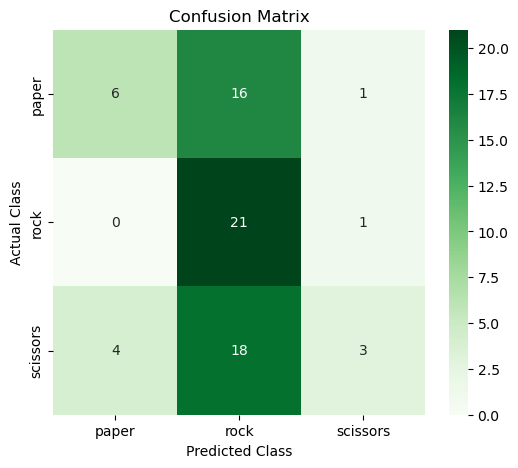

In [117]:
incorrect_indices_personalized_b_1 = np.where(y_pred_personalized_b_1 != y_personalized_b)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_personalized_b_1)} out of {len(y_personalized_b)}")
p=[('Predicted', x)  for x in class_names]
b=[('Actual', x)  for x in class_names]
df = pd.DataFrame(result_personalized_b_1, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model1_cf=np.array(pd.DataFrame(result_personalized_b_1,columns=class_names,index=class_names))
plt.figure(figsize=(6,5))
sns.heatmap(result_personalized_b_1, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()


In [118]:
precision, recall, f1, accuracy = metrics_from_confusion(result_personalized_b_1)
print(f'------------------------personalized dataset with black background performance metrics for model 1 (from confusion matrix)------------------------')
print(f'precision = {np.mean(precision)}')
print(f'recall = {np.mean(recall)}')
print(f'accuracy = {accuracy}')
print(f'f1_score = {np.mean(f1)}')

------------------------personalized dataset with black background performance metrics for model 1 (from confusion matrix)------------------------
precision = 0.5272727272727272
recall = 0.4451383399209486
accuracy = 0.42857142857142855
f1_score = 0.3696969696969697


<h3>Model 2 testing on custom datasets</h3>

<h4>Testing on heterogeneous backgrounds</h4>

In [119]:
result_personalized_2=confusion_matrix(y_personalized, y_pred_personalized_2,labels=[0,1,2])

Incorrectly classified samples: 31 out of 47


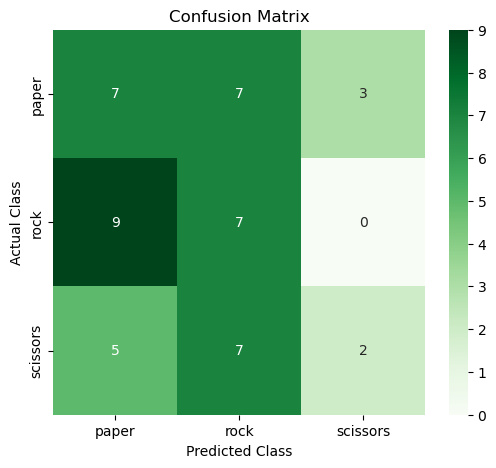

In [120]:
incorrect_indices_personalized_2 = np.where(y_pred_personalized_2 != y_personalized)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_personalized_2)} out of {len(y_personalized)}")
p=[('Predicted', x)  for x in class_names]
b=[('Actual', x)  for x in class_names]
df = pd.DataFrame(result_personalized_2, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model2_cf=np.array(pd.DataFrame(result_personalized_2,columns=class_names,index=class_names))
plt.figure(figsize=(6,5))
sns.heatmap(result_personalized_2, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()


In [121]:
precision, recall, f1, accuracy = metrics_from_confusion(result_personalized_2)
print(f'------------------------personalized dataset performance metrics for model 2 (from confusion matrix)------------------------')
print(f'precision = {np.mean(precision)}')
print(f'recall = {np.mean(recall)}')
print(f'accuracy = {accuracy}')
print(f'f1_score = {np.mean(f1)}')


------------------------personalized dataset performance metrics for model 2 (from confusion matrix)------------------------
precision = 0.35555555555555557
recall = 0.33070728291316526
accuracy = 0.3404255319148936
f1_score = 0.319108582266477


<h4>Testing on homogeneous backgrounds</h4>

In [122]:
result_personalized_b_2=confusion_matrix(y_personalized_b, y_pred_personalized_b_2,labels=[0,1,2])

Incorrectly classified samples: 15 out of 70


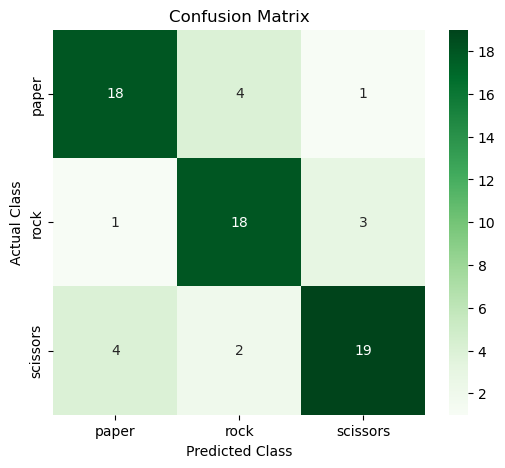

In [123]:
incorrect_indices_personalized_b_2 = np.where(y_pred_personalized_b_2 != y_personalized_b)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_personalized_b_2)} out of {len(y_personalized_b)}")
p=[('Predicted', x)  for x in class_names]
b=[('Actual', x)  for x in class_names]
df = pd.DataFrame(result_personalized_b_2, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model1_cf=np.array(pd.DataFrame(result_personalized_b_2,columns=class_names,index=class_names))
plt.figure(figsize=(6,5))
sns.heatmap(result_personalized_b_2, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()


In [124]:
precision, recall, f1, accuracy = metrics_from_confusion(result_personalized_b_2)
print(f'------------------------personalized dataset with black background performance metrics for model 2 (from confusion matrix)------------------------')
print(f'precision = {np.mean(precision)}')
print(f'recall = {np.mean(recall)}')
print(f'accuracy = {accuracy}')
print(f'f1_score = {np.mean(f1)}')

------------------------personalized dataset with black background performance metrics for model 2 (from confusion matrix)------------------------
precision = 0.7862318840579711
recall = 0.7869301712779974
accuracy = 0.7857142857142857
f1_score = 0.7856280193236715


In [125]:
import json
import numpy as np

def convert(v):
    """Convert non-JSON-serializable objects."""
    if isinstance(v, np.ndarray):
        return v.tolist()
    if isinstance(v, (np.integer, np.floating)):
        return v.item()
    return v

data_to_save = {
    "y_test": y_test,
    "img_test": img_test,
    "y_personalized": y_personalized,
    "img_personalized": img_personalized,
    "y_personalized_b": y_personalized_b,
    "img_personalized_b": img_personalized_b,

    "y_pred_1": y_pred_1,
    "y_pred_2": y_pred_2,
    "y_pred_3": y_pred_3,
    "y_pred_personalized": y_pred_personalized,
    "y_pred_personalized_1": y_pred_personalized_1,
    "y_pred_personalized_2": y_pred_personalized_2,
    "y_pred_personalized_b": y_pred_personalized_b,
    "y_pred_personalized_b_1": y_pred_personalized_b_1,
    "y_pred_personalized_b_2": y_pred_personalized_b_2,
    
    
}

for name, value in data_to_save.items():
    value = convert(value)

    with open(f"./performance/{name}.json", "w") as f:
        json.dump(value, f, indent=4)

print("All JSON files saved successfully.")

All JSON files saved successfully.


In [126]:

if not os.path.exists("model_1.keras"):
        model_1.save("model_1.keras")
if not os.path.exists("model_2.keras"):
        model_2.save("model_2.keras")
if not os.path.exists("model_3.keras"):
        model_3.save("model_3.keras")